## Evaluacion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve
import os

os.makedirs("../outputs", exist_ok=True)

lr_proba  = np.load("../data/lr_proba.npy")
xgb_proba = np.load("../data/xgb_proba.npy")
y_test    = np.load("../data/y_test.npy")

print(f"y_test shape    : {y_test.shape}")
print(f"Default rate    : {y_test.mean():.1%}")

y_test shape    : (97761,)
Default rate    : 27.2%


In [2]:
def ks_statistic(y_true, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return (tpr - fpr).max()

def evaluate_model(name, y_true, y_proba):
    auc   = roc_auc_score(y_true, y_proba)
    ks    = ks_statistic(y_true, y_proba)
    gini  = 2 * auc - 1
    brier = brier_score_loss(y_true, y_proba)

    print(f"\n{'─'*44}")
    print(f"  {name}")
    print(f"{'─'*44}")
    print(f"  ROC-AUC : {auc:.4f}  (benchmark banca: >0.75)")
    print(f"  KS      : {ks:.4f}  (benchmark banca: >0.35)")
    print(f"  Gini    : {gini:.4f} (benchmark banca: >0.50)")
    print(f"  Brier   : {brier:.4f} (↓ mejor)")
    return {"name": name, "auc": auc, "ks": ks, "gini": gini, "brier": brier}

res_lr  = evaluate_model("Logística Baseline", y_test, lr_proba)
res_xgb = evaluate_model("XGBoost",            y_test, xgb_proba)


────────────────────────────────────────────
  Logística Baseline
────────────────────────────────────────────
  ROC-AUC : 0.6876  (benchmark banca: >0.75)
  KS      : 0.2736  (benchmark banca: >0.35)
  Gini    : 0.3753 (benchmark banca: >0.50)
  Brier   : 0.2173 (↓ mejor)

────────────────────────────────────────────
  XGBoost
────────────────────────────────────────────
  ROC-AUC : 0.6951  (benchmark banca: >0.75)
  KS      : 0.2835  (benchmark banca: >0.35)
  Gini    : 0.3903 (benchmark banca: >0.50)
  Brier   : 0.2210 (↓ mejor)


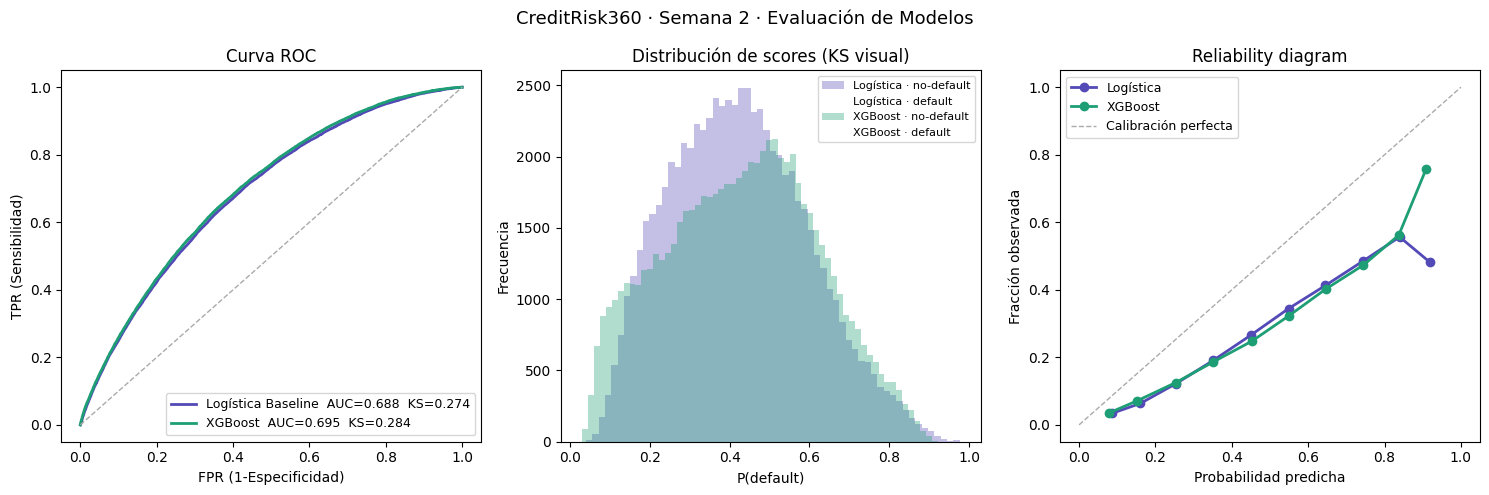

In [3]:
COLORS = {"lr": "#534AB7", "xgb": "#1D9E75"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ROC
for res, proba, key in [(res_lr, lr_proba, "lr"), (res_xgb, xgb_proba, "xgb")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=COLORS[key], lw=2,
                 label=f"{res['name']}  AUC={res['auc']:.3f}  KS={res['ks']:.3f}")
axes[0].plot([0,1],[0,1], "--", color="#aaa", lw=1)
axes[0].set(title="Curva ROC", xlabel="FPR (1-Especificidad)", ylabel="TPR (Sensibilidad)")
axes[0].legend(fontsize=9)

# Distribución de scores por clase
for proba, key, label in [(lr_proba,"lr","Logística"), (xgb_proba,"xgb","XGBoost")]:
    axes[1].hist(proba[y_test==0], bins=60, alpha=0.35, color=COLORS[key],
                 label=f"{label} · no-default")
    axes[1].hist(proba[y_test==1], bins=60, alpha=0.0, color=COLORS[key],
                 histtype="step", lw=2, label=f"{label} · default")
axes[1].set(title="Distribución de scores (KS visual)",
            xlabel="P(default)", ylabel="Frecuencia")
axes[1].legend(fontsize=8)

# Reliability diagram
for proba, key, label in [(lr_proba,"lr","Logística"), (xgb_proba,"xgb","XGBoost")]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    axes[2].plot(mean_pred, frac_pos, "o-", color=COLORS[key], lw=2, label=label)
axes[2].plot([0,1],[0,1], "--", color="#aaa", lw=1, label="Calibración perfecta")
axes[2].set(title="Reliability diagram", xlabel="Probabilidad predicha",
            ylabel="Fracción observada")
axes[2].legend(fontsize=9)

plt.suptitle("CreditRisk360 · Semana 2 · Evaluación de Modelos", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/semana2_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
summary = pd.DataFrame([res_lr, res_xgb]).set_index("name").round(4)
display(summary)
summary.to_csv("../outputs/semana2_metrics_summary.csv")
print("Resumen guardado ✓")

,auc,ks,gini,brier
name,,,,
Logística Baseline,0.6876,0.2736,0.3753,0.2173
XGBoost,0.6951,0.2835,0.3903,0.2210


Resumen guardado ✓
